# Tema central del proyecto

Desafío dado: Podemos afirmar que, a partir de los datos dados, que ultimamente está temblando más?

**Pregunta de investigación:** ¿El aumento aparente en el número de terremotos registrados por año se debe a un aumento real de la actividad sísmica, o a mejoras en la capacidad de detección/reporte a lo largo del tiempo?


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



import numpy as np

df = pd.read_csv('earthquakes_usgs.csv', index_col=0)
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 310535 entries, 0 to 310534
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   time       310535 non-null  datetime64[ns, UTC]
 1   latitude   310535 non-null  float64            
 2   longitude  310535 non-null  float64            
 3   depth      309808 non-null  float64            
 4   mag        310535 non-null  float64            
 5   magType    310534 non-null  object             
 6   place      310535 non-null  object             
 7   type       310535 non-null  object             
 8   status     310535 non-null  object             
 9   net        310535 non-null  object             
 10  nst        120314 non-null  float64            
 11  rms        260523 non-null  float64            
 12  year       310535 non-null  int32              
dtypes: datetime64[ns, UTC](1), float64(6), int32(1), object(5)
memory usage: 32.0+ MB


/tmp/ipykernel_873125/4152722408.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])


,time,latitude,longitude,depth,mag,magType,place,type,status,net,nst,rms,year
0,1900-01-05 19:00:00+00:00,-3.0,102.0,NaN,7.0,ms,"Southern Sumatra, Indonesia",earthquake,reviewed,cent,NaN,NaN,1900
1,1900-01-11 09:07:00+00:00,-5.0,148.0,NaN,7.0,ms,Bismarck Sea,earthquake,reviewed,cent,NaN,NaN,1900
2,1900-01-20 06:33:00+00:00,20.0,-105.0,NaN,7.3,mw,"Jalisco, Mexico",earthquake,reviewed,cent,NaN,NaN,1900
3,1900-01-31 19:22:00+00:00,48.0,146.0,450.0,7.5,mj,Sea of Okhotsk,earthquake,reviewed,cent,NaN,NaN,1900
4,1900-04-30 22:41:14+00:00,36.9,-121.6,NaN,4.5,ml,"Near Aromas, California",earthquake,reviewed,ushis,NaN,NaN,1900


In [5]:
df.isnull().sum()

time              0
latitude          0
longitude         0
depth           727
mag               0
magType           1
place             0
type              0
status            0
net               0
nst          190221
rms           50012
year              0
dtype: int64

Se puede observar una gran cantidad de datos faltantes para las variables de nst y rms, lo que sigmifica una limitación de calidad o cobertura instrimental

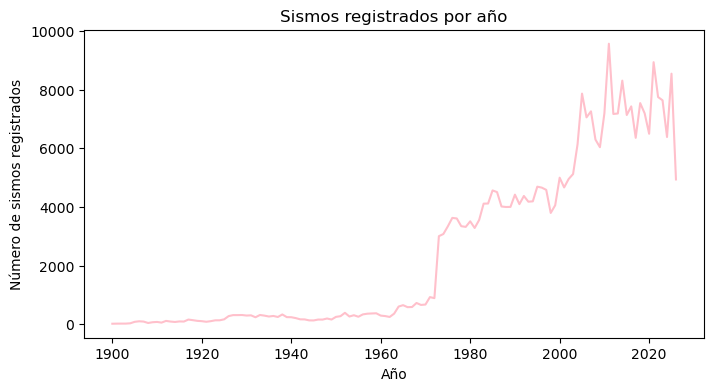

In [13]:
plt.figure(figsize=(8,4))
df['year'].value_counts().sort_index().plot(color='pink')
plt.xlabel('Año')
plt.ylabel('Número de sismos registrados')
plt.title('Sismos registrados por año')
plt.show()

El hecho de que se observe un incremento en el reporte de temblores a lo largo de los años, no significa necesariamente que actualmente tiemble más, sino que podría debersa en el desarrollo tecnológico de instrumentos de detección de sismos.

**¿La magnitud mínima detectada cambia con el tiempo?**

<Axes: xlabel='year', ylabel='mag'>

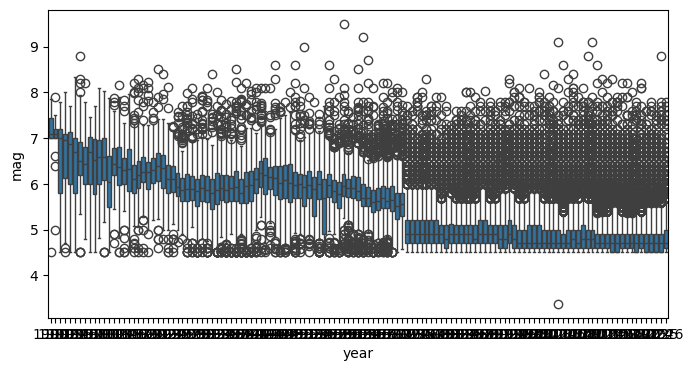

In [7]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='year', y='mag')  # o agrupa por década si hay demasiados años

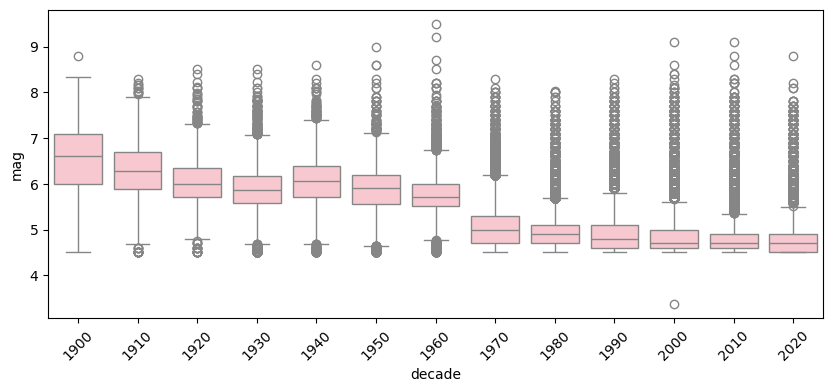

In [9]:
df['decade'] = (df['year'] // 10) * 10
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='decade', y='mag', color='pink')
plt.xticks(rotation=45)
plt.show()

Si la magnitud mínima detectada baja con el tiempo, es evidencia de mejor instrumentación (se detectan sismos más pequeños que antes no se registraban).

**Cobertura instrumental a través del tiempo**

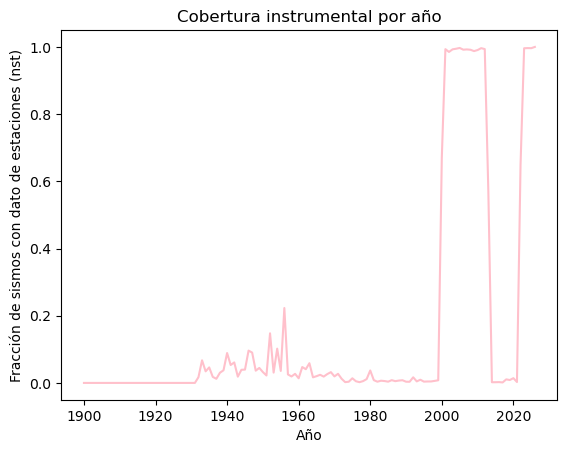

In [15]:
cobertura = df.groupby('year')['nst'].apply(lambda x: x.notnull().mean())
plt.plot(cobertura, color='pink')
plt.xlabel('Año')
plt.ylabel('Fracción de sismos con dato de estaciones (nst)')
plt.title('Cobertura instrumental por año')
plt.show()

**Relación magnitud-profundidad**

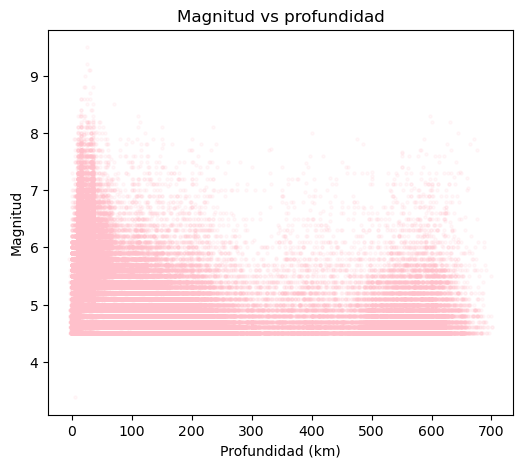

In [17]:
plt.figure(figsize=(6,5))
plt.scatter(df['depth'], df['mag'], alpha=0.1, s=5, color='pink')
plt.xlabel('Profundidad (km)')
plt.ylabel('Magnitud')
plt.title('Magnitud vs profundidad')
plt.show()

**Distribución geográfica**

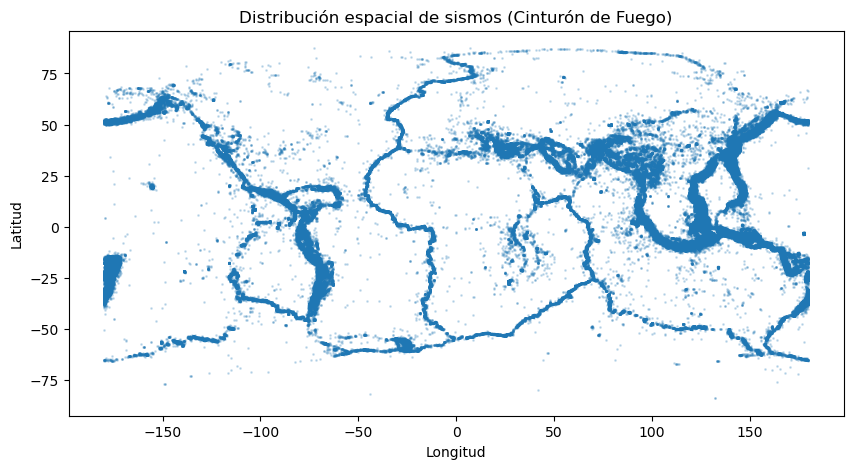

In [32]:
plt.figure(figsize=(10,5))
plt.scatter(df['longitude'], df['latitude'], s=1, alpha=0.2)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución espacial de sismos (Cinturón de Fuego)')
plt.show()

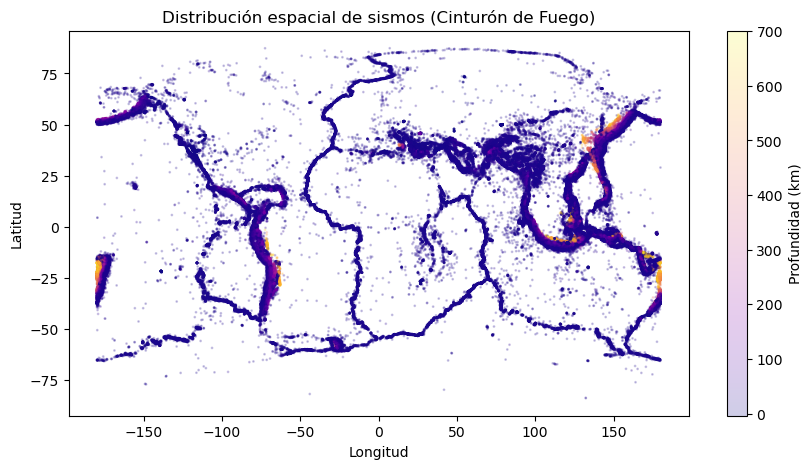

In [25]:
plt.figure(figsize=(10,5))
sc = plt.scatter(df['longitude'], df['latitude'],
                 c=df['depth'],
                 s=1, alpha=0.2, cmap='plasma')
plt.colorbar(sc, label='Profundidad (km)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución espacial de sismos (Cinturón de Fuego)')
plt.show()

**Incorporamos contexto**

Dividimos por tipo, con tal de poder dicernir entre eventos como: terremotos, explosión nuclear, etc. Adicionalmente se puede dividir por rango de magnitud y observar si la tendencia por año cambia

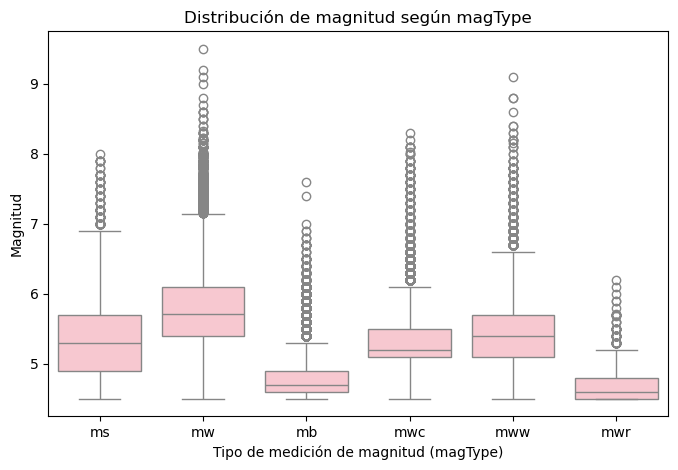

In [34]:
# No usar todos los magType, solo usar los que tienen mas datos (ver header y data de magType)
top_magtypes = df['magType'].value_counts().head(6).index
df_sub = df[df['magType'].isin(top_magtypes)]

plt.figure(figsize=(8,5))
sns.boxplot(data=df_sub, x='magType', y='mag', color='pink')
plt.xlabel('Tipo de medición de magnitud (magType)')
plt.ylabel('Magnitud')
plt.title('Distribución de magnitud según magType')
plt.show()

**Clasificación utilizada:**

- mb (magnitud de ondas de cuerpo) es el tipo más usado (233.504 registros) y tiene la distribución más comprimida y baja: mediana ≈ 4.7, con poca dispersión.
- mw, mww y mwc (todas variantes de "magnitud de momento", el estándar moderno más preciso para sismos grandes) tienen medianas más altas (~5.4-5.7) y colas más largas hacia magnitudes extremas (hasta 9+).
- ms (magnitud de ondas superficiales) queda en un punto intermedio.

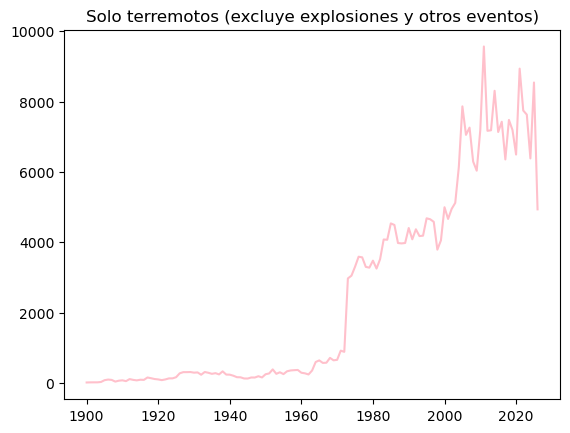

In [27]:
df_quake = df[df['type'] == 'earthquake']
plt.plot(df_quake.groupby('year').size(), color='pink')
plt.title('Solo terremotos (excluye explosiones y otros eventos)')
plt.show()

Utilizando la division por tipo podemos estudiar la tendencia de sismos grandes, los cuales los consideramos a una magnitud >=6

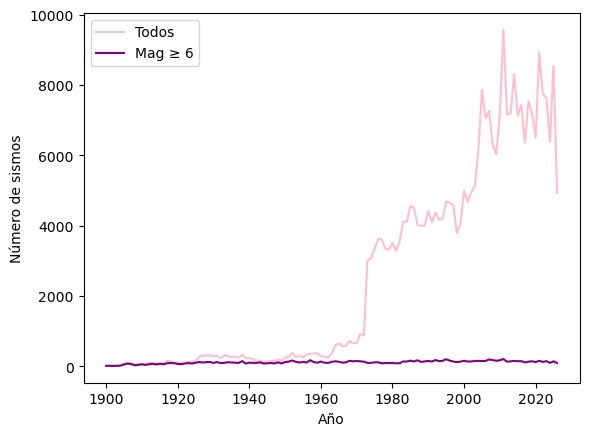

In [29]:
grandes = df[df['mag'] >= 6].groupby('year').size()
todos = df.groupby('year').size()

plt.plot(todos, label='Todos', color = 'pink')
plt.plot(grandes, label='Mag ≥ 6', color = 'purple')
plt.legend()
plt.xlabel('Año')
plt.ylabel('Número de sismos')
plt.show()

Se puede observar que la línea de "todos" sube fuertemente en relación al tiempo transcurrido, pero la de "mag ≥ 6" es casi plana, lo que nos proporciona evidencia al argumento definido anteriormente: el aumento es de detección, no de actividad real.

A partir de los patrones observados en nuestro EDA (en particular, la relación entre profundidad y magnitud, y las diferencias por magType/región), se puede proponer el siguiente problema de ML como posible continuación de este análisis.


****Qué se intentaría predecir?****

Utilizando la variable target = mag, se podría llegar a utilizar como una variable de evaluación de riesgo, aún cuando no se podría predecir el cuando del evento.


****Qué features se utilizarían como info de entrada?****

- depth → Para encontrar en el scatter algún patrón (or lack therof jajaj) entre profundidad y magnitud.
- latitude, longitude → Para observar las diferencias regionales en el tipo de sismicidad (área de subducción, falla, etc).
- magType → Distintos tipos de medición pueden tener sesgos sistemáticos distintos.
- type → filtrando dependiendo si es terremoto, explosión, etc.


****Clasificación o regresión?****

Debido a que mag es una variable continua (numérica), se trata de un problema de regresión. La clasificación predice categorías discretas, mientras que regresión predice un valor continuo. Adicionalmente se puede generar variables discretas si se diferencia entre tipo de sismos según su magnitud (sismo, terremoto, megaterremoto).


****Qué observaciones del EDA sugieren que hay información útil?****

- Se puede ver en los gráficos anteriores que la profundidad varía sistemáticamente con la magnitud o la región, lo que sugiere que las features geográficas son un tipo de señal.
- Al ver el gráfico de magnitud segun magType se confirma que esta ultima variable si aporta información, pero se tendría que ver si el modelo podría estar aprendiendo el método de medición en vez del proceso físico


****Dificultades que se pueden anticipar****

- las variables de nst y rms tienen una cantidad inmensa de datos faltantes, lo quedria deberse a que no se solian registrar en epocas antiguas.
- El sesgo de detección (se profundiza en la sección extra) puede generar que el modelo aprenda patrones erroneos si se entrena con datos de todas las epocas sin corregir segun este mismo sesg

# Extra

Al pensar en como se distribuyen los sismos segun la magnitud recordé que la forma en la que aumentan los sismos en terminos de esta magnitud es según una escala logaritmica (escala logaritmica en energía liberada). lo que nos dice que en una diferencia de 1 en magnitud no es solo "un poquito mas fuerte", sino que es aprox 31.6 veces mas de energía liberada y aprox 10 veces mayor en terminos de amplitud de onda, por lo que al comparar los sismos de tipo mb (mediana 4.7) y mw (mediana 5.7) se ve como una diferencia minima, pero se trata de un salto de un orden de magnitud (que en mi opinión no es menor).

**Relación de Gutenberg-Richter**

En sismología existe una relación empírica, la cual nos dice que el número de sismos de magnitud ≥ M decrece exponencialmente con M. Es decir, si graficamos el conteo de sismos versus magnitud en escala logarítmica (eje y), debería verse aproximadamente una línea recta. 

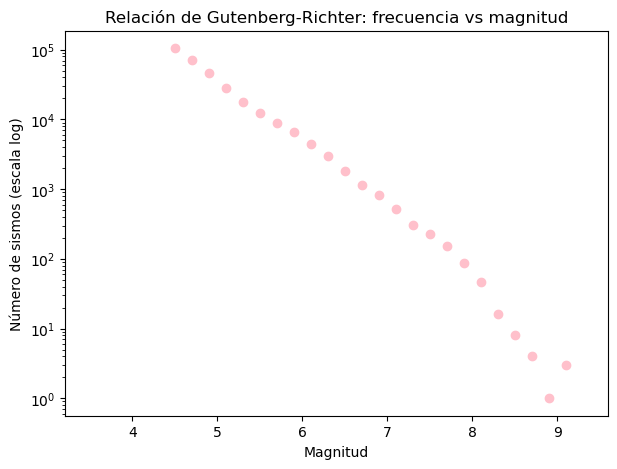

In [41]:
bins = np.arange(3.4, 9.6, 0.2)
counts, edges = np.histogram(df_quake['mag'], bins=bins)
centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(7,5))
plt.scatter(centers, counts, color='pink')
plt.yscale('log')
plt.xlabel('Magnitud')
plt.ylabel('Número de sismos (escala log)')
plt.title('Relación de Gutenberg-Richter: frecuencia vs magnitud')
plt.show()

Con esto confirmamos la relacion de Gutenberg-Richter



- Confirma que los datos siguen este patrón sísmico conocido (la relación es casi lineal en escala log), entonces nos sirve para validar la calidad del dataset.

**Sesgo de detección**
Como la escala es logarítmica, los sismos pequeños son muchísimo más numerosos que los grandes. Si con el tiempo mejora la instrumentación y se empieza a detectar mas de esos sismos pequeños (que antes quedaban bajo el umbral de detección, por falta de desarrollo tecnológico), el conteo total por año sube.
Entonces podemos decir que la Ley de Gutenberg-Richter explica por qué un sesgo de detección relativamente pequeño en magnitudes bajas puede producir un salto muy grande en el conteo total observado cada año.

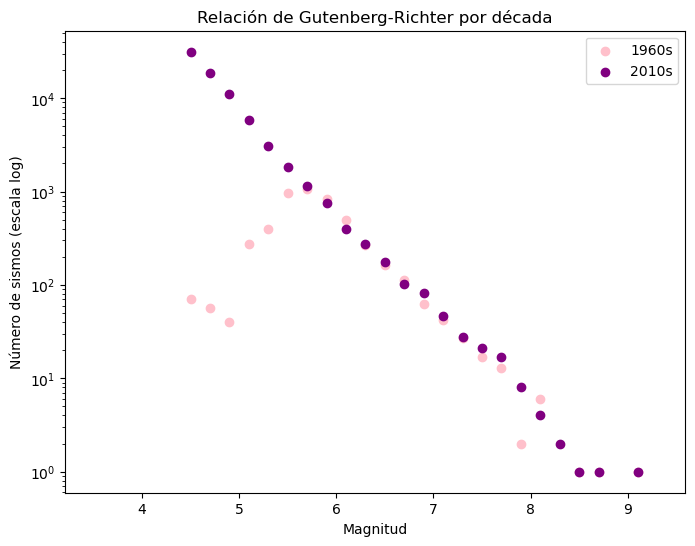

In [45]:

# para analizar solo la actividad sísmica 
df_quake = df[df['type'] == 'earthquake']

# Definimos décadas que a comparar y agregamos una vaiable de colores para que quede bonito 

decadas = [1960, 2010]
colores = ['pink', 'purple']


bins = np.arange(3.4, 9.6, 0.2)

plt.figure(figsize=(8,6))

# hacer un ciclo for para recorrer cada década
for dec, color in zip(decadas, colores):

    sub = df_quake[(df_quake['year'] >= dec) & (df_quake['year'] < dec + 10)]

    counts, edges = np.histogram(sub['mag'], bins=bins)

    # Punto medio de cada intervalo para graficarlo como un solo valor de x si no no funciona y uno se frustra muuuucho
    centers = (edges[:-1] + edges[1:]) / 2

    
    plt.scatter(centers, counts, label=f'{dec}s', color=color)


plt.yscale('log')

plt.xlabel('Magnitud')
plt.ylabel('Número de sismos (escala log)')
plt.title('Relación de Gutenberg-Richter por década')
plt.legend()  
plt.show()

Esto es para visualizar el sesgo de detección que mencionaba.

las curvas coinciden bien en magnitudes altas, pero divergen fuertemente en magnitudes bajas, donde 2010s tiene muchos más eventos registrados que 1960s. Ademas que debido al desarrollo en tecnologia de detección ayuda a minimizar outliers.

**Qué significa esto?**
Esto nos muestra la evidencia más directa de que el aumento histórico en el número de sismos registrados se explica principalmente por mejoras en la capacidad de detección de sismos de menor magnitud, y no por un aumento real en la actividad sísmica del planeta